# **Analisis performa algoritma XGBoost, Random forest, dan Logistic Regression dalam mengklasifikasikan keamanan URL dari serangan phising**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")
print("Library berhasil dimuat.")

Library berhasil dimuat.


In [2]:
df=pd.read_excel(r"/content/phishing.xlsx")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


**1. DATA UNDERSTANDING**

In [3]:
print("DATA UNDERSTANDING")
print(f"Dataset terdiri dari {df.shape[0]} baris dan {df.shape[1]} kolom.")

print("\nInformasi Fitur:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

DATA UNDERSTANDING
Dataset terdiri dari 11054 baris dan 32 kolom.

Informasi Fitur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-nul

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,...,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000
mean,5526.500000,0.313914,-0.633345,0.738737,0.700561,0.741632,-0.734938,0.064049,0.251040,-0.336711,...,0.613353,0.816899,0.061335,0.377239,0.287407,-0.483626,0.721549,0.343948,0.719739,0.113986
std,3191.159272,0.949495,0.765973,0.674024,0.713625,0.670837,0.678165,0.817492,0.911856,0.941651,...,0.789845,0.576807,0.998162,0.926158,0.827680,0.875314,0.692395,0.569936,0.694276,0.993527
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2763.250000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5526.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8289.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11053.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.isnull().sum()

,0
Index,0
UsingIP,0
LongURL,0
ShortURL,0
Symbol@,0
Redirecting//,0
PrefixSuffix-,0
SubDomains,0
HTTPS,0
DomainRegLen,0


In [5]:
df.duplicated().sum()

np.int64(0)

**2. DATA PREPROCESSING**

**Cek Outlier**

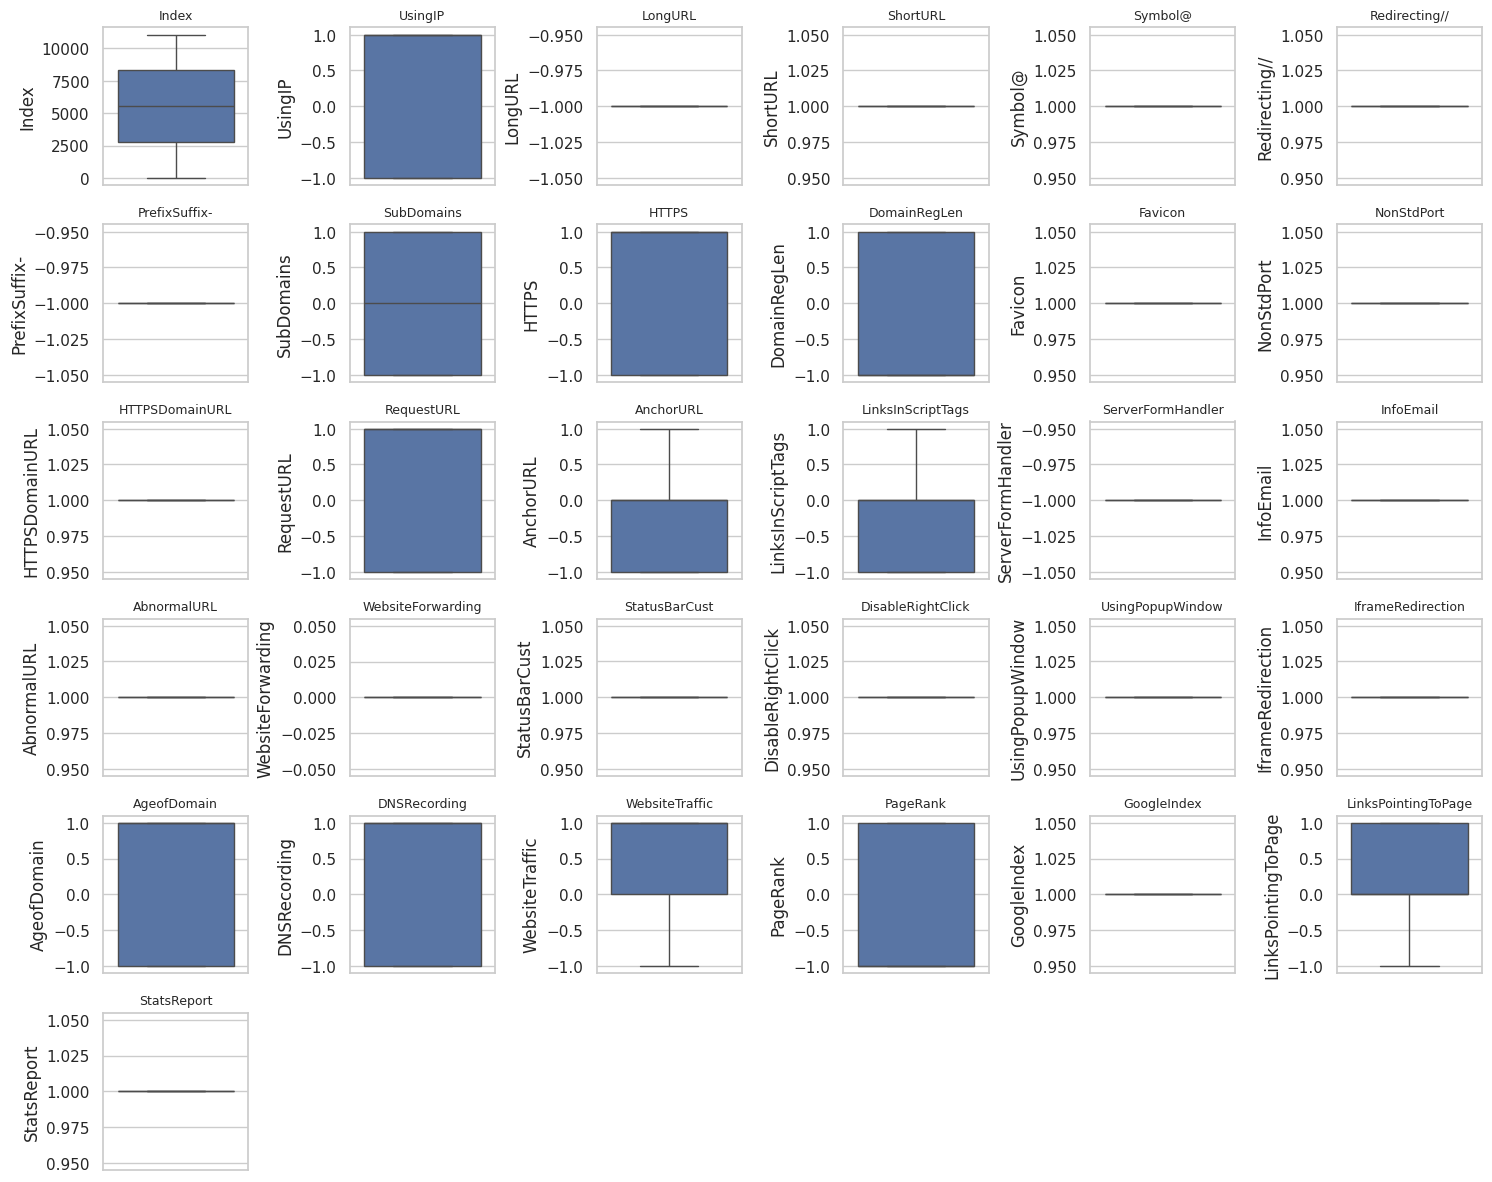

In [15]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

rows = math.ceil(len(fitur) / 6)

plt.figure(figsize=(15, rows * 2))

for i, col in enumerate(fitur):
    plt.subplot(rows, 6, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=9)

plt.tight_layout()
plt.show()

**Handle Outlier**

In [16]:
column = ['LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'GoogleIndex', 'StatsReport']

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1


df_clean = df[~((df[column] < (Q1 - 1.5 * IQR)) |
                (df[column] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original rows: {df.shape[0]}")
print(f"Rows after outlier removal: {df_clean.shape[0]}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

df = df_clean

Original rows: 11054
Rows after outlier removal: 11054
Rows removed: 0


**3. EXPLORATION DATA ANALYSIS**

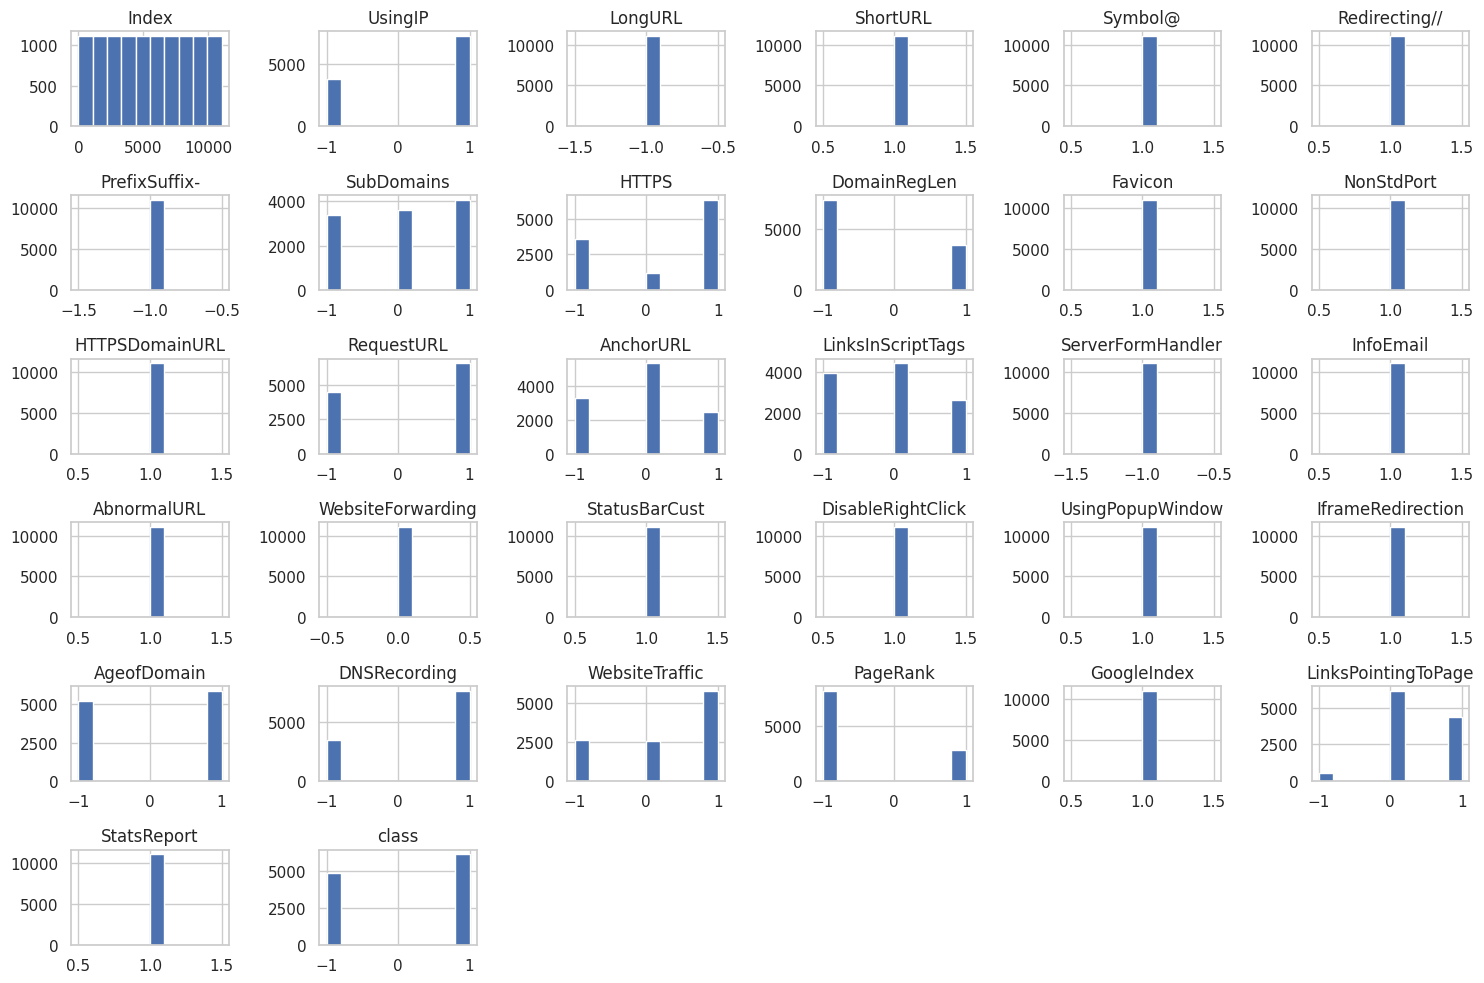

In [18]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

/tmp/ipykernel_14926/4224276021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='magma')


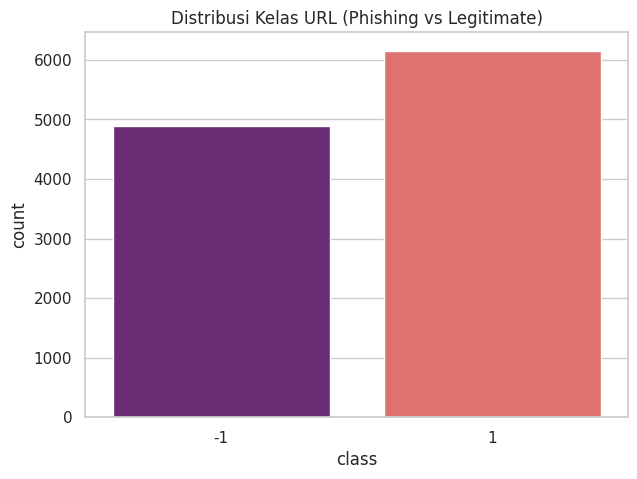

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(x='class', data=df, palette='magma')
plt.title('Distribusi Kelas URL (Phishing vs Legitimate)')
plt.show()

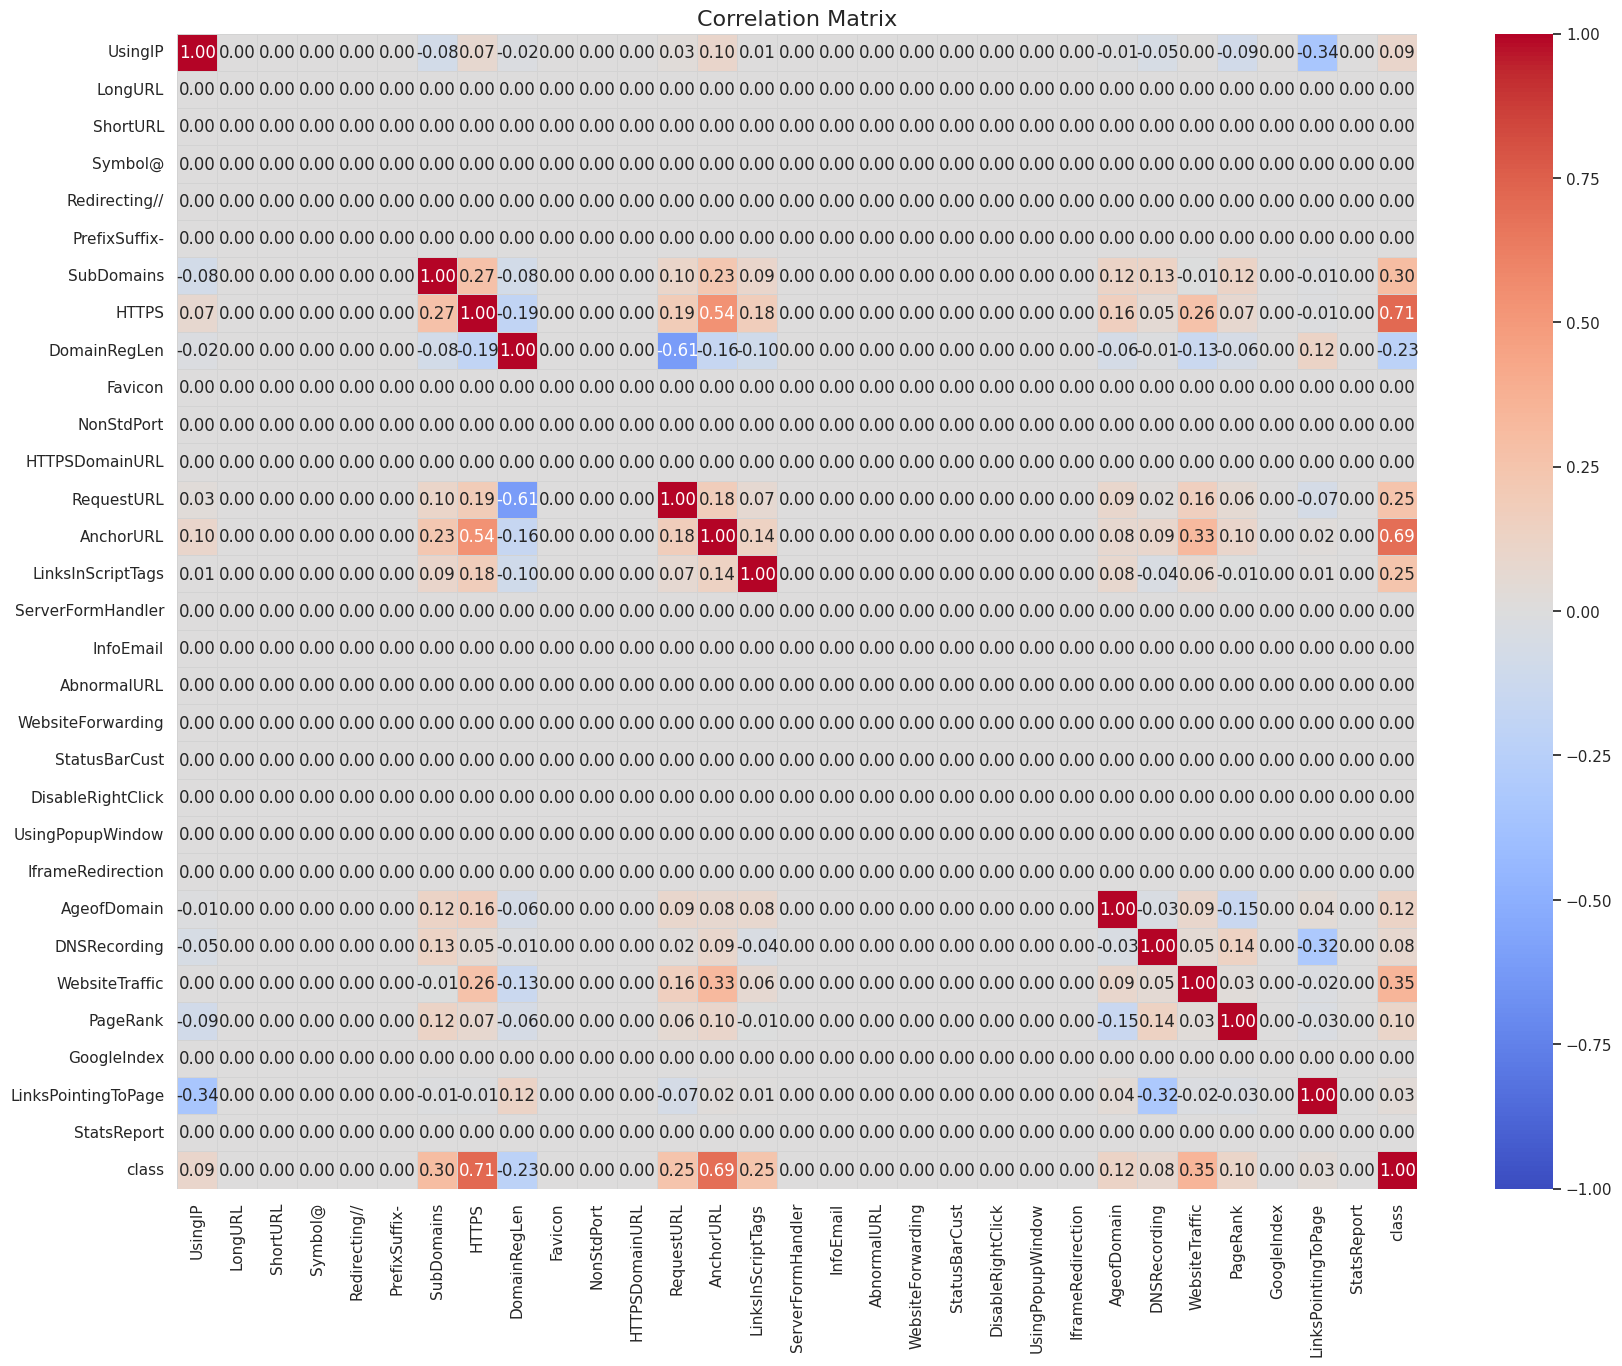

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_numeric = df.drop(columns=['Index'], errors='ignore')

corr_matrix = df_numeric.corr()

corr_matrix = corr_matrix.fillna(0)

plt.figure(figsize=(20, 15))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            linecolor='lightgrey',
            center=0,
            vmin=-1, vmax=1)

plt.title('Correlation Matrix', fontsize=16)
plt.show()

**4. SPLIT DATA**

In [22]:
from sklearn.model_selection import train_test_split

#split Data
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [24]:
ratios = [0.3, 0.2, 0.1]
eval_data = []

for r in ratios:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(X, y, test_size=r, random_state=42)

    rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42).fit(X_train_tmp, y_train_tmp)
    acc_rf = accuracy_score(y_test_tmp, rf.predict(X_test_tmp))

    xgb = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=42).fit(X_train_tmp, y_train_tmp.replace({-1: 0}))
    acc_xgb = accuracy_score(y_test_tmp.replace({-1: 0}), xgb.predict(X_test_tmp))

    lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42).fit(X_train_tmp, y_train_tmp)
    acc_lr = accuracy_score(y_test_tmp, lr.predict(X_test_tmp))

    eval_data.append({
        'Rasio Split': f"{int((1-r)*100)}:{int(r*100)}",
        'Random Forest': f"{acc_rf:.6f}",
        'XGBoost': f"{acc_xgb:.6f}",
        'Logistic Regression': f"{acc_lr:.6f}"
    })

df_eval = pd.DataFrame(eval_data)
print("TABEL PENGUJIAN 3 PEMBAGIAN DATA")
display(df_eval)

TABEL PENGUJIAN 3 PEMBAGIAN DATA


,Rasio Split,Random Forest,XGBoost,Logistic Regression
0,70:30,0.956286,0.952668,0.912572
1,80:20,0.955676,0.954319,0.919041
2,90:10,0.949367,0.951175,0.918626


**5. MODEL BUILDING & HYPERPARAMETER TUNNING**

In [34]:
from sklearn.model_selection import GridSearchCV

params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

params_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6]
}

params_knn = {'n_neighbors': [3, 5, 7]}
params_lr = {'C': [0.1, 1.0, 10.0], 'solver': ['liblinear']}

print("--- HYPERPARAMETER TUNING (80:20) ---")

def perform_tuning(model, params, X_train, y_train, model_name):
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"\n{model_name}")
    print(f"Best Parameter: {grid.best_params_}")
    print(f"Akurasi       : {grid.best_score_ * 100:.2f}%")

perform_tuning(RandomForestClassifier(random_state=42), params_rf, X_train, y_train, "Random Forest")
perform_tuning(XGBClassifier(eval_metric='logloss', random_state=42), params_xgb, X_train, y_train.replace({-1: 0}), "XGBoost")
perform_tuning(LogisticRegression(max_iter=1000, random_state=42), params_lr, X_train, y_train, "Logistic Regression")

--- HYPERPARAMETER TUNING (80:20) ---

Random Forest
Best Parameter: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Akurasi       : 95.47%

XGBoost
Best Parameter: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Akurasi       : 95.06%

Logistic Regression
Best Parameter: {'C': 0.1, 'solver': 'liblinear'}
Akurasi       : 91.10%


**6. EVALUASI MODEL**

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

eval_metrics = []
models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
}

for r in ratios:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(X, y, test_size=r, random_state=42)

    for name, model in models.items():
        if name == 'XGBoost':
            model.fit(X_train_tmp, y_train_tmp.replace({-1: 0}))
            y_pred = model.predict(X_test_tmp)
            y_test_eval = y_test_tmp.replace({-1: 0})
        else:
            model.fit(X_train_tmp, y_train_tmp)
            y_pred = model.predict(X_test_tmp)
            y_test_eval = y_test_tmp

        eval_metrics.append({
            'Model': name,
            'Split': f"{int((1-r)*100)}:{int(r*100)}",
            'Accuracy (%)': accuracy_score(y_test_eval, y_pred) * 100,
            'Precision (%)': precision_score(y_test_eval, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_test_eval, y_pred, average='weighted') * 100,
            'F1-score (%)': f1_score(y_test_eval, y_pred, average='weighted') * 100
        })

df_metrics = pd.DataFrame(eval_metrics)
display(df_metrics)

,Model,Split,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Random Forest,70:30,95.628580,95.633244,95.628580,95.623468
1,XGBoost,70:30,95.266807,95.276586,95.266807,95.259611
2,Logistic Regression,70:30,91.257160,91.275176,91.257160,91.233583
3,Random Forest,80:20,95.567616,95.569683,95.567616,95.563564
4,XGBoost,80:20,95.431931,95.431091,95.431931,95.429114
5,Logistic Regression,80:20,91.904116,91.916364,91.904116,91.886768
6,Random Forest,90:10,94.936709,94.947881,94.936709,94.930986
7,XGBoost,90:10,95.117541,95.116635,95.117541,95.115833
8,Logistic Regression,90:10,91.862568,91.882808,91.862568,91.848027


<Figure size 600x500 with 0 Axes>

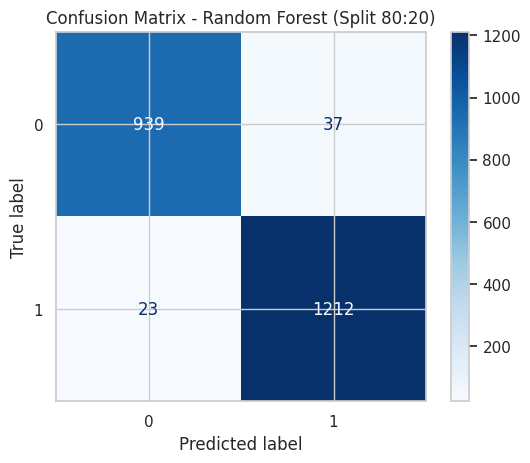

<Figure size 600x500 with 0 Axes>

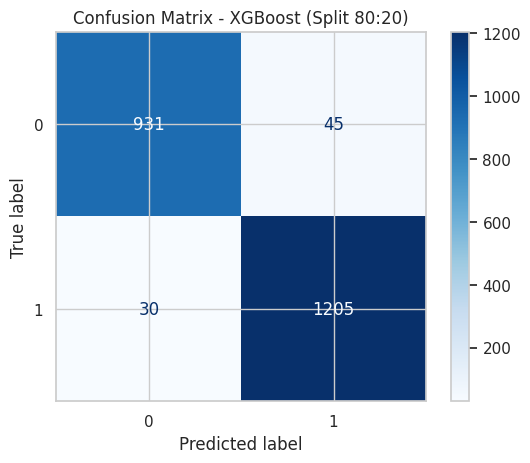

<Figure size 600x500 with 0 Axes>

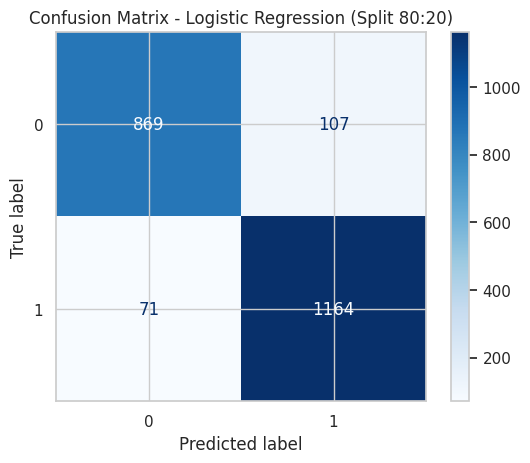

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train_fix, X_test_fix, y_train_fix, y_test_fix = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    y_test_cm = y_test_fix.replace({-1: 0}) if name == 'XGBoost' else y_test_fix

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test_cm, model.predict(X_test_fix))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Split 80:20)')
    plt.show()

**7. MODEL COMPARASION**

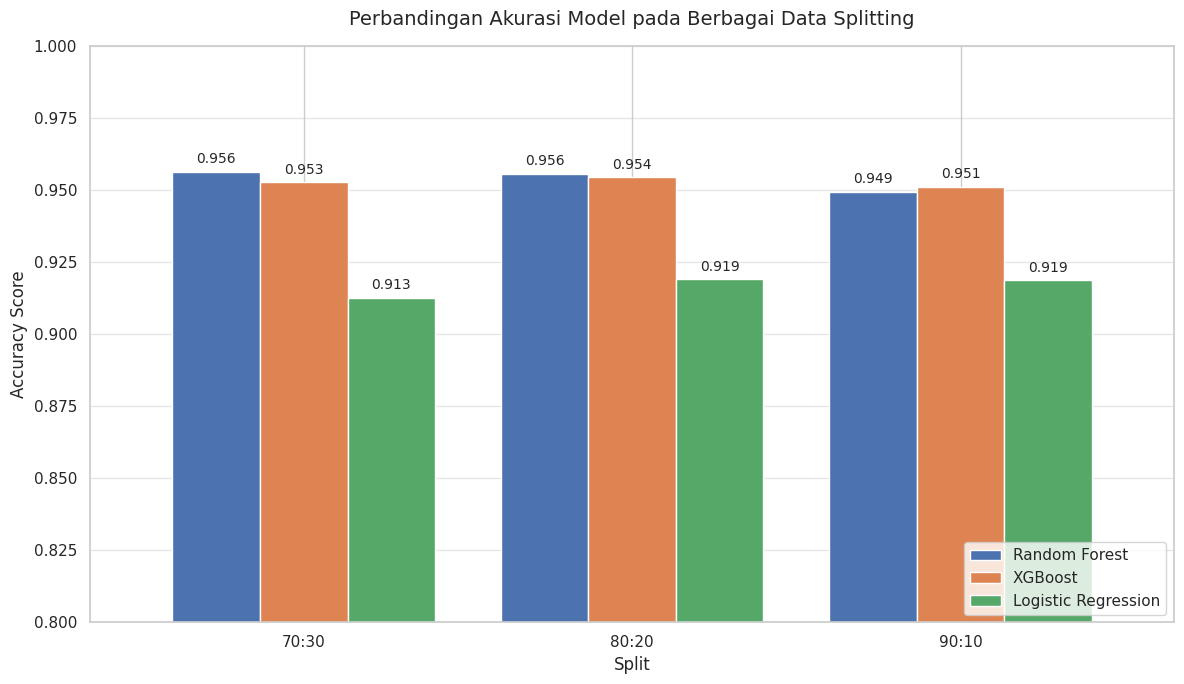

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_eval.copy()
for col in ['Random Forest', 'XGBoost', 'Logistic Regression']:
    df_plot[col] = df_plot[col].astype(float)

sns.set_style("whitegrid")
ax = df_plot.set_index('Rasio Split').plot(kind='bar',
                                           figsize=(12, 7),
                                           color=['#4c72b0', '#dd8452', '#55a868'],
                                           width=0.8)

plt.title('Perbandingan Akurasi Model pada Berbagai Data Splitting', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Split', fontsize=12)

plt.ylim(0.800, 1.000)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.legend(loc='lower right', frameon=True)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.tight_layout()
plt.show()